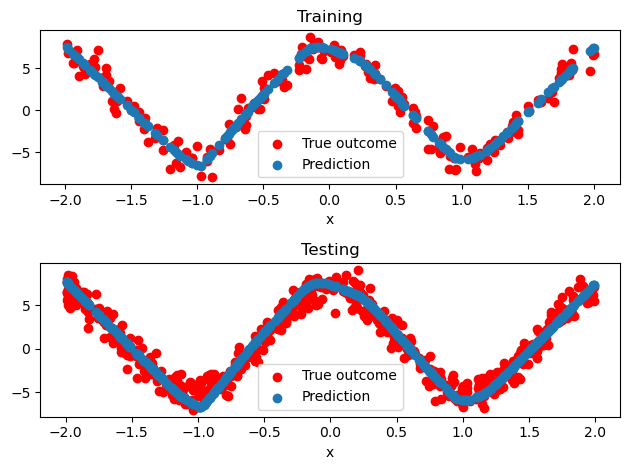

KeyboardInterrupt: 

In [1]:
import sys
sys.path.append('../functions')
from CS_sim_helper import sim_CS,sim_CS_wrapper, generate_sim_data,check_overfitting, transform_X_poly,transform_X
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from models import NueralNet, logistic_regression
from xgboost import XGBRegressor
import torch.nn as nn
import numpy as np
# models_l = [LinearRegression, RandomForestRegressor, NueralNet, XGBRegressor]
# model_kwargs_l = [{},{'min_samples_leaf':6},{'input_size': 1, 'h_sizes':[40,40]}, {'n_estimators':100,'max_depth':1, 'subsample':0.7}]
# r = sim_CS(L=0.9, level = 0, models_l = models_l, model_kwargs_l = model_kwargs_l, 
#    N = 100, N_test =500, p = 1, error_sd = 1, 
#    data_sim_func = generate_sim_data, data_kwargs = {'beta':np.array([-2,2,3]),'transform_func': transform_X_poly,'uniform_range_x':[-2,2]},
#    center_G = True, center_pred = False, 
#    use_true_contour = False,  n_boot = 100)


# models_l = [LinearRegression]
# model_kwargs_l = [{}]
# r = sim_CS(L=0.9, level = 0, models_l = models_l, model_kwargs_l = model_kwargs_l, 
#    N = 100, N_test =500, p = 3, error_sd = 1, 
#    data_sim_func = generate_sim_data, data_kwargs = {'beta':np.array([-2,2,3]),'transform_func': None,'uniform_range_x':[-2,2]},
#    center_G = True, center_pred = False, 
#    use_true_contour = False,  n_boot = 100)


# {'input_size': 4, 'h_sizes':[40,40],'out_act':'sigmoid', 'loss_fn': nn.BCELoss()}
# {'min_samples_leaf':6}
# return_plot does not seem to be working, can only be False
check_overfitting(model = NueralNet, model_kwargs = { 'n_iter':200,'patience':100,'input_size': 1, 'h_sizes':[40,40]}, 
          N = 400, N_test =500, p = 1, error_sd = 1, 
          data_sim_func = generate_sim_data, data_kwargs = {'transform_func':transform_X, 'beta':np.array([1,2,3,4]), 'uniform_range_x':[-2,2]})
r = sim_CS(L=0.9, level = 2, models_l = [NueralNet], model_kwargs_l = [ { 'n_iter':200,'patience':100,'input_size': 1, 'h_sizes':[40,40]}], 
   N = 100, N_test =500, p = 1, error_sd = 1, 
   data_sim_func = generate_sim_data, data_kwargs =  {'transform_func':transform_X, 'beta':np.array([1,2,3,4]),'uniform_range_x':[-2,2]},
   center_G = True, center_pred = False, 
   use_true_contour = False,  n_boot = 300, return_plot = False)
print(r)

# check_overfitting(model = XGBRegressor, model_kwargs = {'n_estimators':10,'max_depth':6, 'subsample':0.2}, 
#           N = 100, N_test =200, p = 1, error_sd = 1, 
#           data_sim_func = generate_sim_data, data_kwargs = {'transform_func':transform_X, 'beta':np.array([1,2,3,4]), 'uniform_range_x':[-2,2]})
# r = sim_CS(L=0.9, level = 2, models_l = [XGBRegressor], model_kwargs_l = [{'n_estimators':10,'max_depth':6, 'subsample':0.2}], 
#    N = 100, N_test =500, p = 1, error_sd = 1, 
#    data_sim_func = generate_sim_data, data_kwargs =  {'transform_func':transform_X, 'beta':np.array([1,2,3,4]),'uniform_range_x':[-2,2]},
#    center_G = True, center_pred = False, 
#    use_true_contour = False,  n_boot = 200, return_plot = False)
# print(r)

# check_overfitting(model = RandomForestRegressor, model_kwargs = {'min_samples_leaf':3}, 
#           N = 100, N_test =200, p = 1, error_sd = 1, 
#           data_sim_func = generate_sim_data, data_kwargs = {'transform_func':transform_X, 'beta':np.array([1,2,3,4]), 'uniform_range_x':[-2,2]})
# r = sim_CS(L=0.9, level = 2, models_l = [RandomForestRegressor], model_kwargs_l = [{'min_samples_leaf':6}], 
#    N = 100, N_test =200, p = 1, error_sd = 1, 
#    data_sim_func = generate_sim_data, data_kwargs =  {'transform_func':transform_X, 'beta':np.array([1,2,3,4]),'uniform_range_x':[-2,2]},
#    center_G = True, center_pred = False, 
#    use_true_contour = False,  n_boot = 200, return_plot = False)
# print(r)